In [18]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load Karate Club graph
G = nx.karate_club_graph()

# Global tracking variables
iteration_count = 0
all_iterations = []
metrics_by_iteration = {}
pos = None

imported the necessary libraries, loaded the karate club graph and declared the golbal variables. now definig the necessary functions

In [ ]:
def modularity_matrix(subgraph):
    """Calculate modularity matrix B for a subgraph"""
    nodes = list(subgraph.nodes())
    n = len(nodes)
    A = nx.adjacency_matrix(subgraph, nodelist=nodes).todense()
    degrees = [subgraph.degree(node) for node in nodes]
    k = np.array(degrees)
    m = subgraph.number_of_edges()
    
    if m == 0:
        return np.zeros((n, n))
    
    B = A - np.outer(k, k) / (2 * m)    #modularity matrix
    return B

def leading_eigenvalue_pair(subgraph):
    """Get leading eigenvalue and eigenvector"""
    B = modularity_matrix(subgraph)
    eigenvalues, eigenvectors = np.linalg.eigh(B)
    idx = np.argmax(eigenvalues)     
    lambda1 = eigenvalues[idx]      #ordering the eigen values to get the leading eigen value
    u1 = eigenvectors[:, idx]
    return lambda1, u1

def split_community(subgraph):
    """Split a community based on leading eigenvector"""
    lambda1, u1 = leading_eigenvalue_pair(subgraph)
    
    if lambda1 <= 1e-10:         #checking conditon with threshold of 1^-10
        return None, None, lambda1   #if eigne value negative it returns none 
    
    nodes = list(subgraph.nodes())
    g1 = [nodes[i] for i in range(len(nodes)) if u1[i] > 0]     #checking each component of eigen vector corresponding to leading eigen value
    g2 = [nodes[i] for i in range(len(nodes)) if u1[i] <= 0]
    
    if len(g1) == 0 or len(g2) == 0:
        return None, None, lambda1   #if no nodes in graph aslo returns none
    
    return g1, g2, lambda1

def compute_all_metrics(iteration, communities):
    """Compute all centrality metrics for nodes within their communities"""
    degree_cent = {}             
    betweenness_cent = {}
    closeness_cent = {}
    clustering_coef = {}
    
    for community in communities:
        if len(community) < 2:    #if there are less than two node in community 0
            for node in community:
                degree_cent[node] = 0.0
                betweenness_cent[node] = 0.0          
                closeness_cent[node] = 0.0
                clustering_coef[node] = 0.0
        else:
            subG = G.subgraph(community)
            deg_c = nx.degree_centrality(subG)        
            bet_c = nx.betweenness_centrality(subG, normalized=True)
            clo_c = nx.closeness_centrality(subG)
            clu_c = nx.clustering(subG)
            
            for node in community:
                degree_cent[node] = deg_c[node]
                betweenness_cent[node] = bet_c[node]
                closeness_cent[node] = clo_c[node]
                clustering_coef[node] = clu_c[node]
    
    metrics_by_iteration[iteration] = {
        'degree': degree_cent.copy(),
        'betweenness': betweenness_cent.copy(),
        'closeness': closeness_cent.copy(),
        'clustering': clustering_coef.copy()
    }
    
    return metrics_by_iteration[iteration]

def recursive_partition(G):
    """Recursively partition graph using spectral modularity"""
    global iteration_count, all_iterations, pos
    pos = nx.spring_layout(G, seed=42, k=1.2, iterations=100)
    all_nodes = list(G.nodes())      
    current_communities = [all_nodes]

    iteration_count=0
    print(f"ITERATION {iteration_count}: Initial State - 1 community with {len(all_nodes)} nodes")
    
    metrics = compute_all_metrics(iteration_count, current_communities)
    all_iterations.append({
        'iteration': iteration_count,
        'communities': [all_nodes],
        'metrics': metrics
    })
    
    
    while True:
        split_occurred = False
        new_communities = []
        
        print(f"\nITERATION {iteration_count}: Checking {len(current_communities)} communities")
        
        for comm_idx, community in enumerate(current_communities):
            current_subgraph = G.subgraph(community)
            g1, g2, lambda1 = split_community(current_subgraph)
            
            if g1 is None:  #if not split
                new_communities.append(community)
                print(f"  Community {comm_idx + 1} ({len(community)} nodes): λ₁ = {lambda1:.6f} - Cannot split")
            
            else:
                split_occurred = True    #else new communities
                new_communities.append(g1)
                new_communities.append(g2)
                print(f"  Community {comm_idx + 1} ({len(community)} nodes): λ₁ = {lambda1:.6f} - Split into {len(g1)} and {len(g2)} nodes")
                
        
        if not split_occurred:
            print(f"\nNo splits occurred - Algorithm complete")
            break
        
        iteration_count+=1
        current_communities = new_communities
        print(f"  Total communities: {len(current_communities)}")
        
        metrics = compute_all_metrics(iteration_count, current_communities)
        all_iterations.append({
            'iteration': iteration_count,
            'communities': [comm.copy() for comm in current_communities],
            'metrics': metrics
        })
        
        
    
    print(f"\nFINAL: {len(current_communities)} communities detected")
    for i, comm in enumerate(current_communities):
        print(f"  Community {i+1}: {len(comm)} nodes")
    
    return current_communities

def visualize_iteration(iteration_idx, save_path=None):
    """Visualize graph at a specific iteration"""
    if iteration_idx >= len(all_iterations):
        iteration_idx = len(all_iterations) - 1
    
    data = all_iterations[iteration_idx]
    communities = data['communities']
    
    colors_palette = ['#667eea', '#f093fb', '#4facfe', '#43e97b', 
                      '#fa709a', '#fee140', '#30cfd0', '#c471ed',
                      '#ff6b6b', '#4ecdc4', '#45b7d1', '#f38181']
    
    node_colors = {}
    for i, comm in enumerate(communities):
        color = colors_palette[i % len(colors_palette)]
        for node in comm:
            node_colors[node] = color
    
    fig, ax = plt.subplots(figsize=(14, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=2, ax=ax, edge_color='#cccccc')
    colors = [node_colors[node] for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=600, alpha=0.9, 
                           ax=ax, edgecolors='white', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold', 
                            font_color='white', ax=ax)
    
    title = f"Iteration {data['iteration']}: {len(communities)} Communit{'y' if len(communities)==1 else 'ies'}"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.axis('off')
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=colors_palette[i % len(colors_palette)], 
                                 markersize=12, label=f'Community {i+1} ({len(comm)} nodes)')
                      for i, comm in enumerate(communities)]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')  #saving figure
    
    plt.show()
    return fig

def plot_metrics_evolution(save_path=None):
    """Plot evolution of metrics using bar plots"""
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    metrics = ['degree', 'betweenness', 'closeness', 'clustering']
    metric_labels = ['Degree Centrality', 'Betweenness Centrality', 
                    'Closeness Centrality', 'Clustering Coefficient']
    
    iterations = sorted(metrics_by_iteration.keys())
    all_nodes = sorted(G.nodes())
    bar_width = 0.8 / len(all_nodes)
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx // 2, idx % 2]
        
        for node_idx, node in enumerate(all_nodes):
            node_values = [metrics_by_iteration[iteration][metric][node] for iteration in iterations]
            positions = [i + (node_idx - len(all_nodes)/2) * bar_width for i in iterations]
            ax.bar(positions, node_values, width=bar_width, 
                   label=f'Node {node}' if idx == 0 and node_idx < 10 else '', alpha=0.8)
        
        ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
        ax.set_ylabel(label, fontsize=14, fontweight='bold')
        ax.set_title(f'{label} Evolution', fontsize=16, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=1, axis='y')
        ax.set_xticks(iterations)
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95, 
                     title='Sample Nodes', title_fontsize=10)
    
    plt.suptitle('Network Metrics Evolution (Bar Plots)', fontsize=18, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    
    plt.show()
    return fig

def plot_individual_metric_line(metric_name, save_path=None):
    """Plot evolution of a single metric using line plot"""
    fig, ax = plt.subplots(figsize=(18, 10))
    
    iterations = sorted(metrics_by_iteration.keys())
    all_nodes = sorted(G.nodes())
    
    metric_labels = {
        'degree': 'Degree Centrality',
        'betweenness': 'Betweenness Centrality',
        'closeness': 'Closeness Centrality',
        'clustering': 'Clustering Coefficient'
    }
    
    label = metric_labels.get(metric_name, metric_name.capitalize())
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_nodes)))
    
    for node_idx, node in enumerate(all_nodes):
        node_values = [metrics_by_iteration[iteration][metric_name][node] for iteration in iterations]
        ax.plot(iterations, node_values, marker='o', label=f'Node {node}', 
               linewidth=2.5, markersize=7, alpha=0.8, color=colors[node_idx])
    
    ax.set_xlabel('Iteration Number', fontsize=15, fontweight='bold')
    ax.set_ylabel(label, fontsize=15, fontweight='bold')
    ax.set_title(f'{label} Evolution (Line Plot)', fontsize=18, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    ax.set_xticks(iterations)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, ncol=2, 
             framealpha=0.95, title='Node ID', title_fontsize=11)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    
    plt.show()
    return fig

In [ ]:
# Main execution
print("="*70)
print("="*70)
print("SPECTRAL MODULARITY COMMUNITY DETECTION")
print("Karate Club Network")
print("="*70)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print("="*70)

# Run partitioning
communities = recursive_partition(G)


DEBUG: Contents of all_iterations
SPECTRAL MODULARITY COMMUNITY DETECTION
Karate Club Network
Nodes: 34, Edges: 78
ITERATION 0: Initial State - 1 community with 34 nodes

ITERATION 1: Checking 1 communities
  Community 1 (34 nodes): λ₁ = 17.107387 - Split into 18 and 16 nodes
  Total communities: 2

ITERATION 2: Checking 2 communities
  Community 1 (18 nodes): λ₁ = 13.085450 - Cannot split
  Community 2 (16 nodes): λ₁ = 13.782361 - Split into 4 and 12 nodes
  Total communities: 3

ITERATION 3: Checking 3 communities
  Community 1 (18 nodes): λ₁ = 13.085450 - Cannot split
  Community 2 (4 nodes): λ₁ = 5.676966 - Cannot split
  Community 3 (12 nodes): λ₁ = 12.893660 - Cannot split

No splits occurred - Algorithm complete

FINAL: 3 communities detected
  Community 1: 18 nodes
  Community 2: 4 nodes
  Community 3: 12 nodes



GENERATING VISUALIZATIONS
Iteration 0...


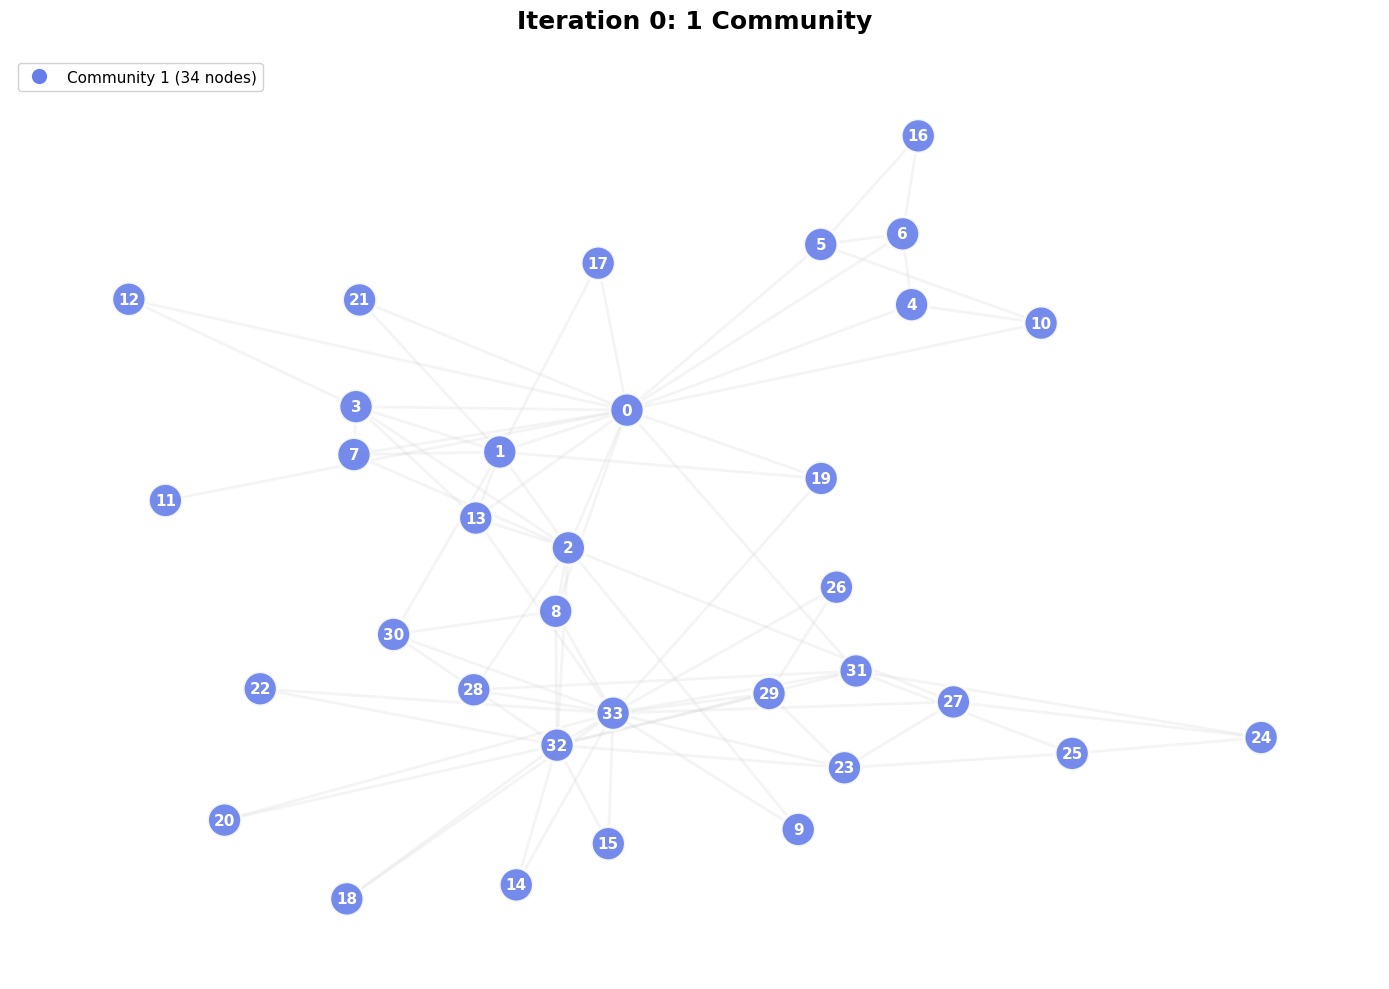

Iteration 1...


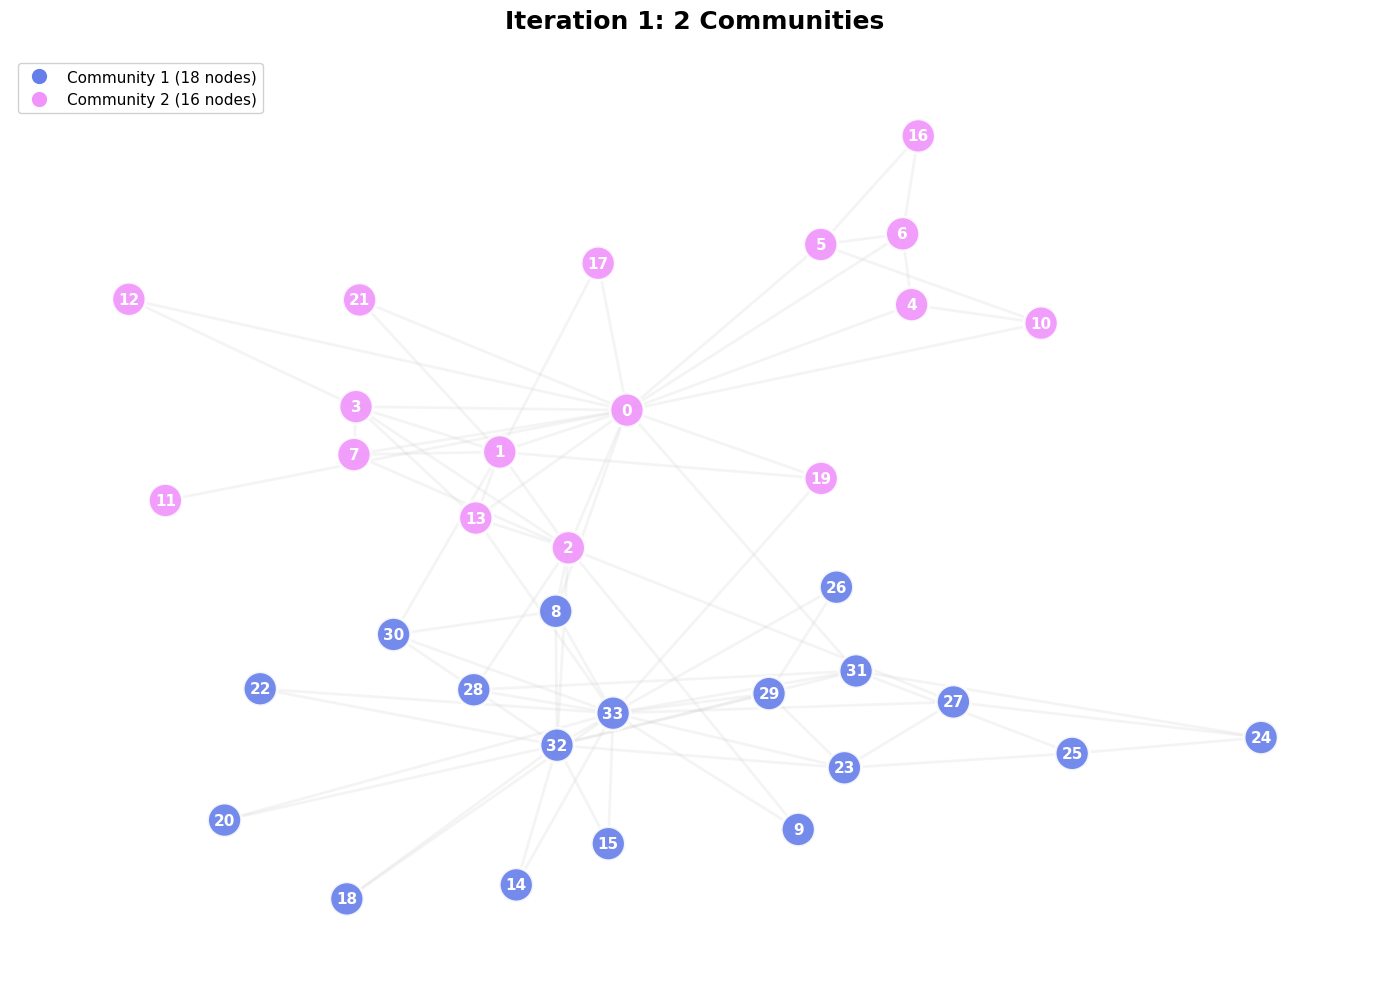

Iteration 2...


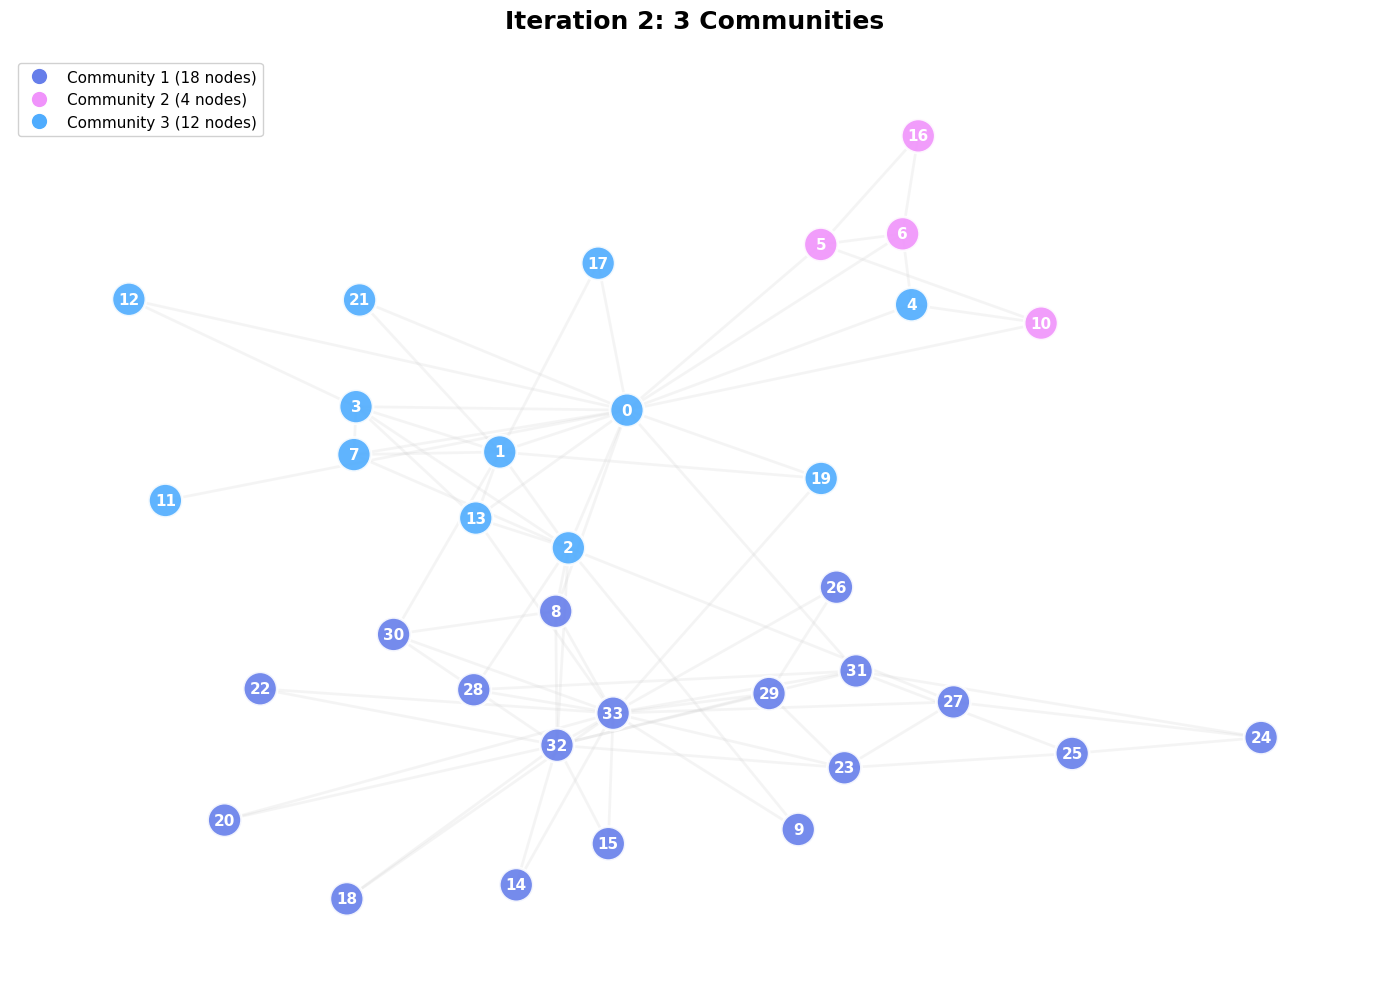

In [21]:
# Visualize iterations
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

for i in range(len(all_iterations)):
    print(f"Iteration {i}...")
    visualize_iteration(i, f'karate_iteration_{i}.png')



Generating combined metrics plot...


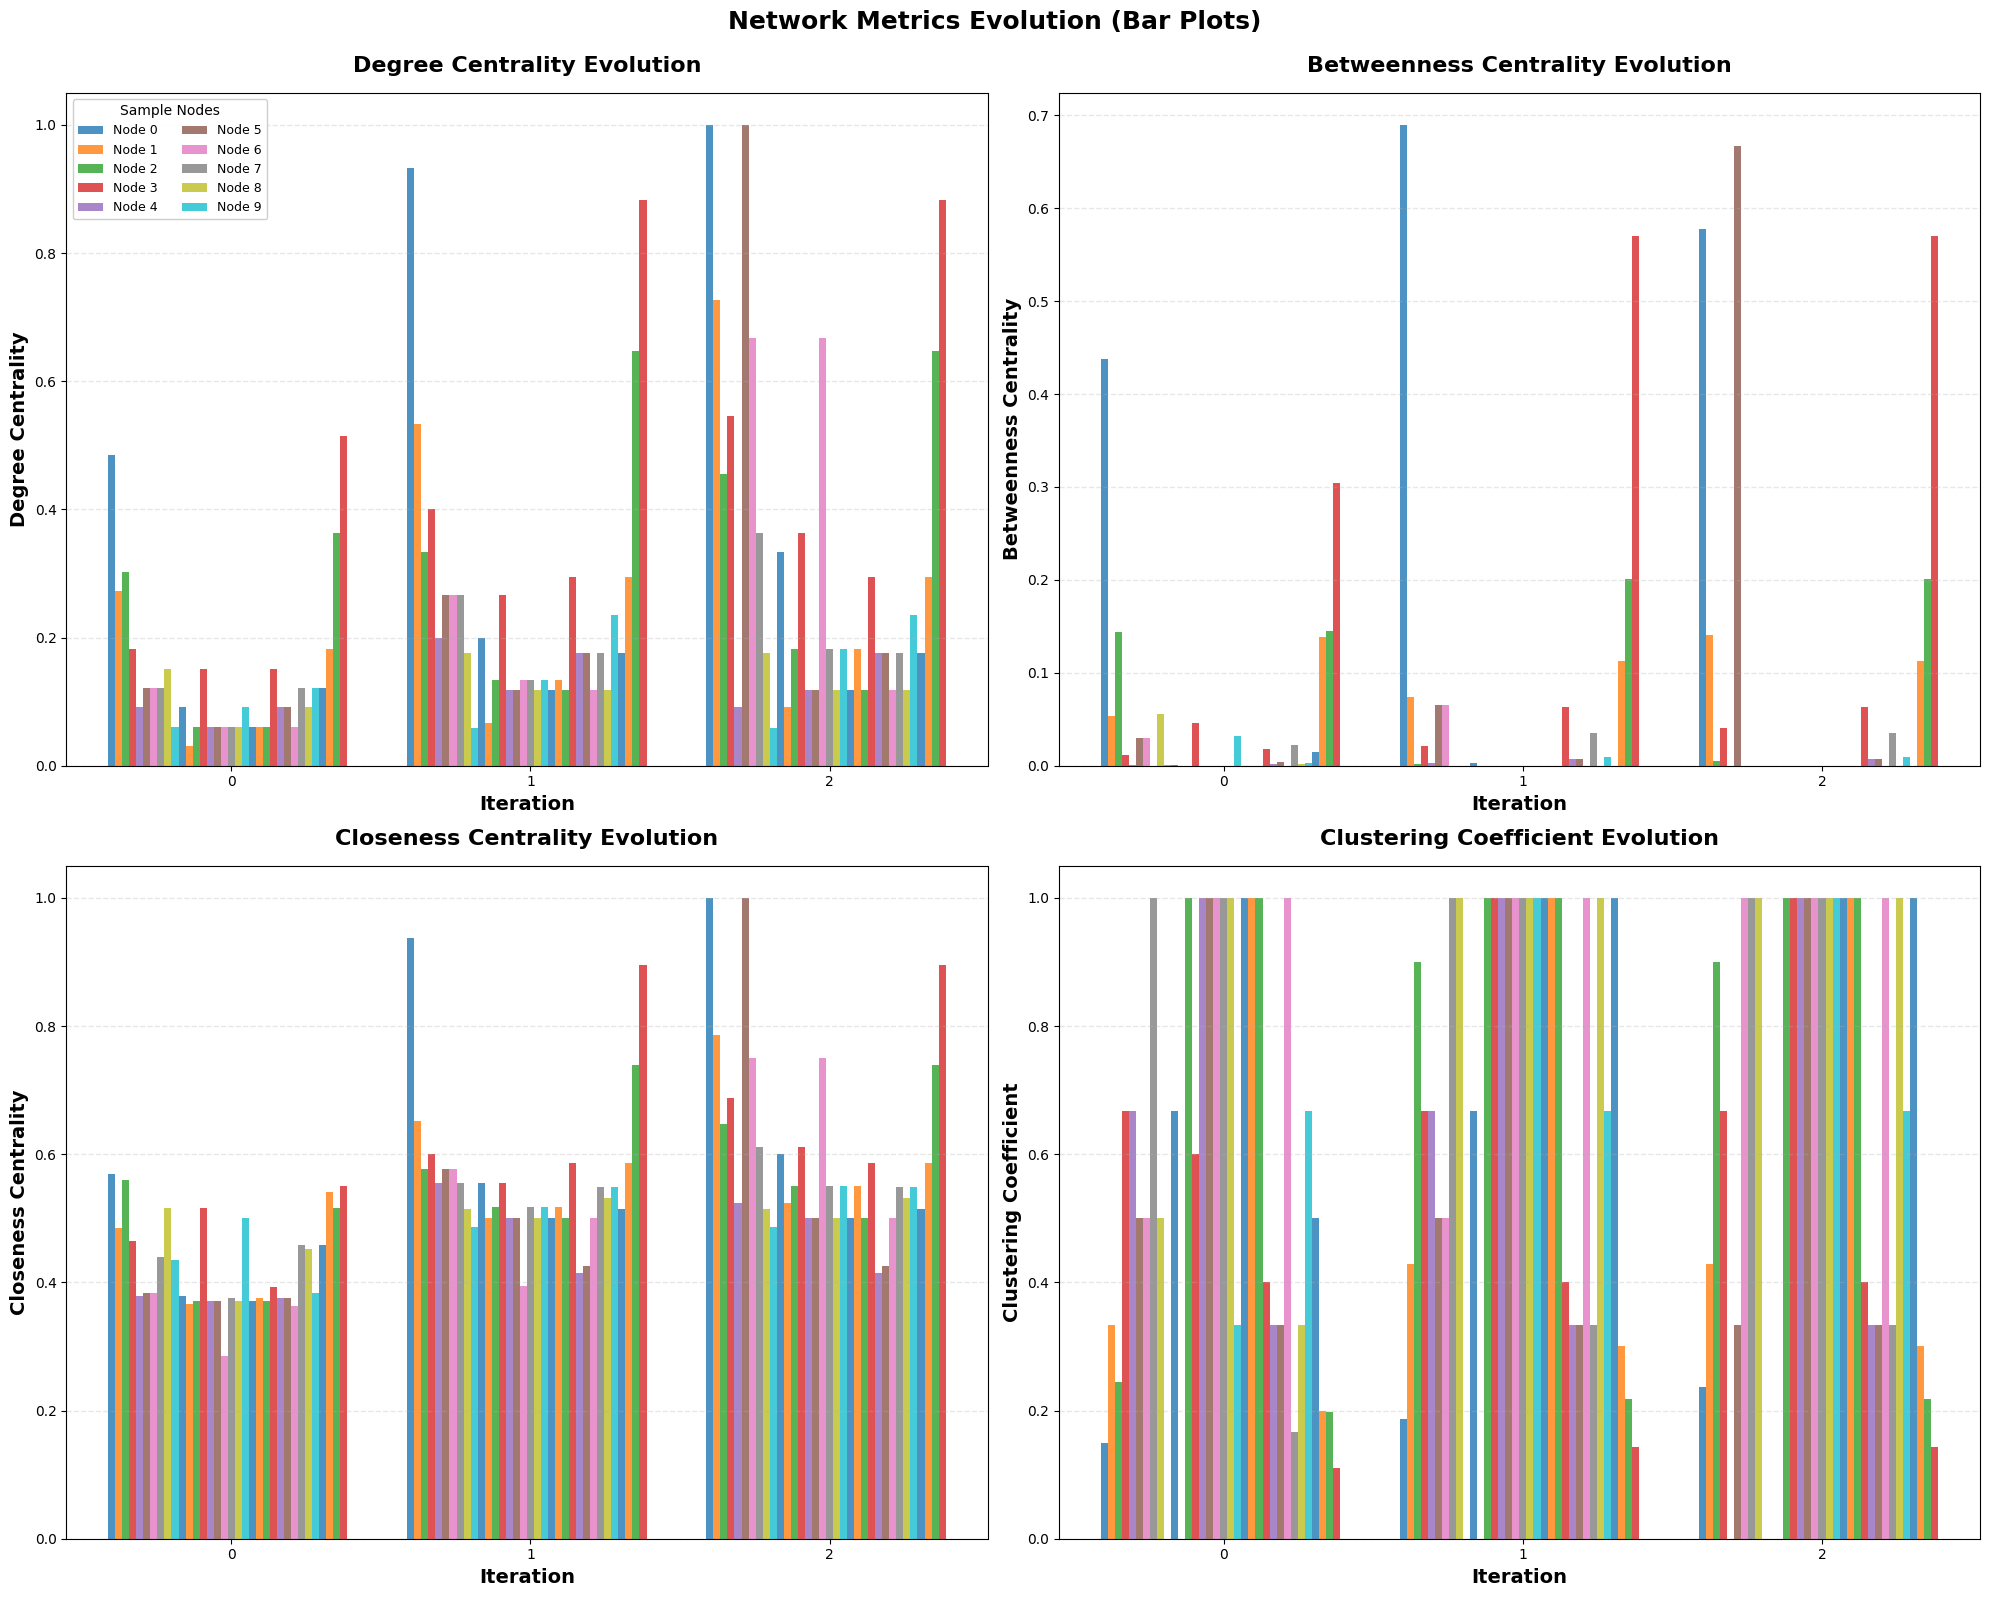


Generating individual metric plots...
  Degree...


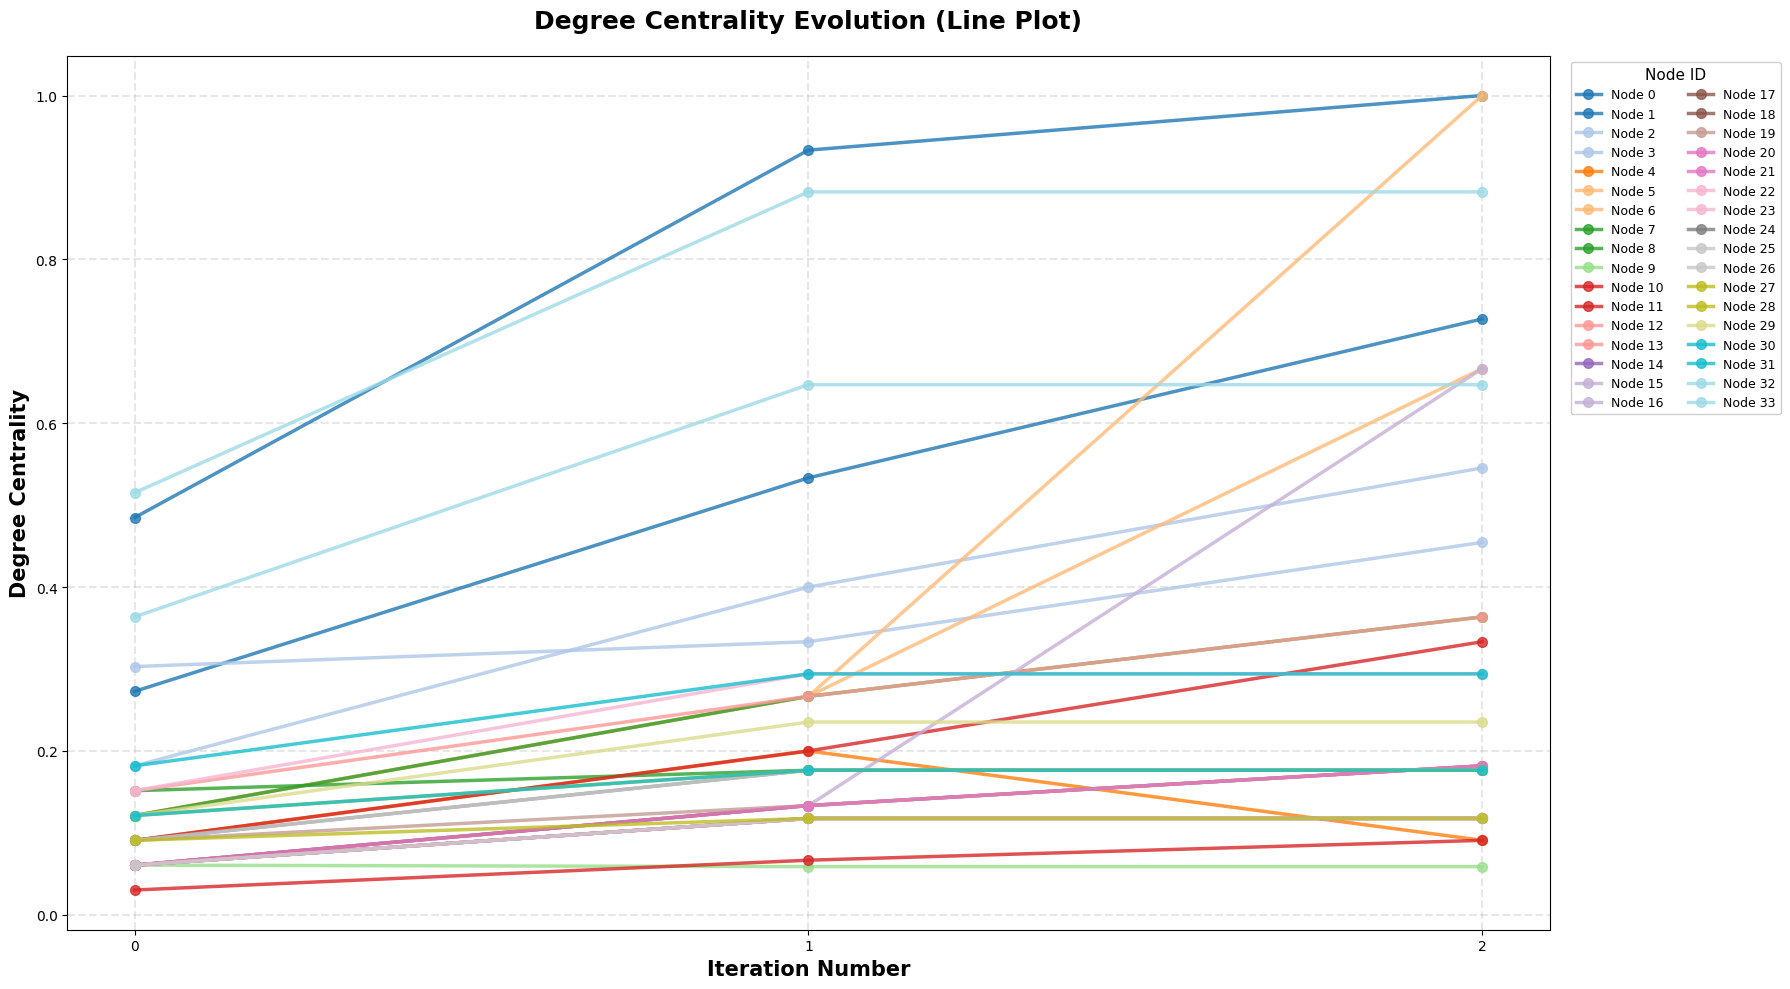

  Betweenness...


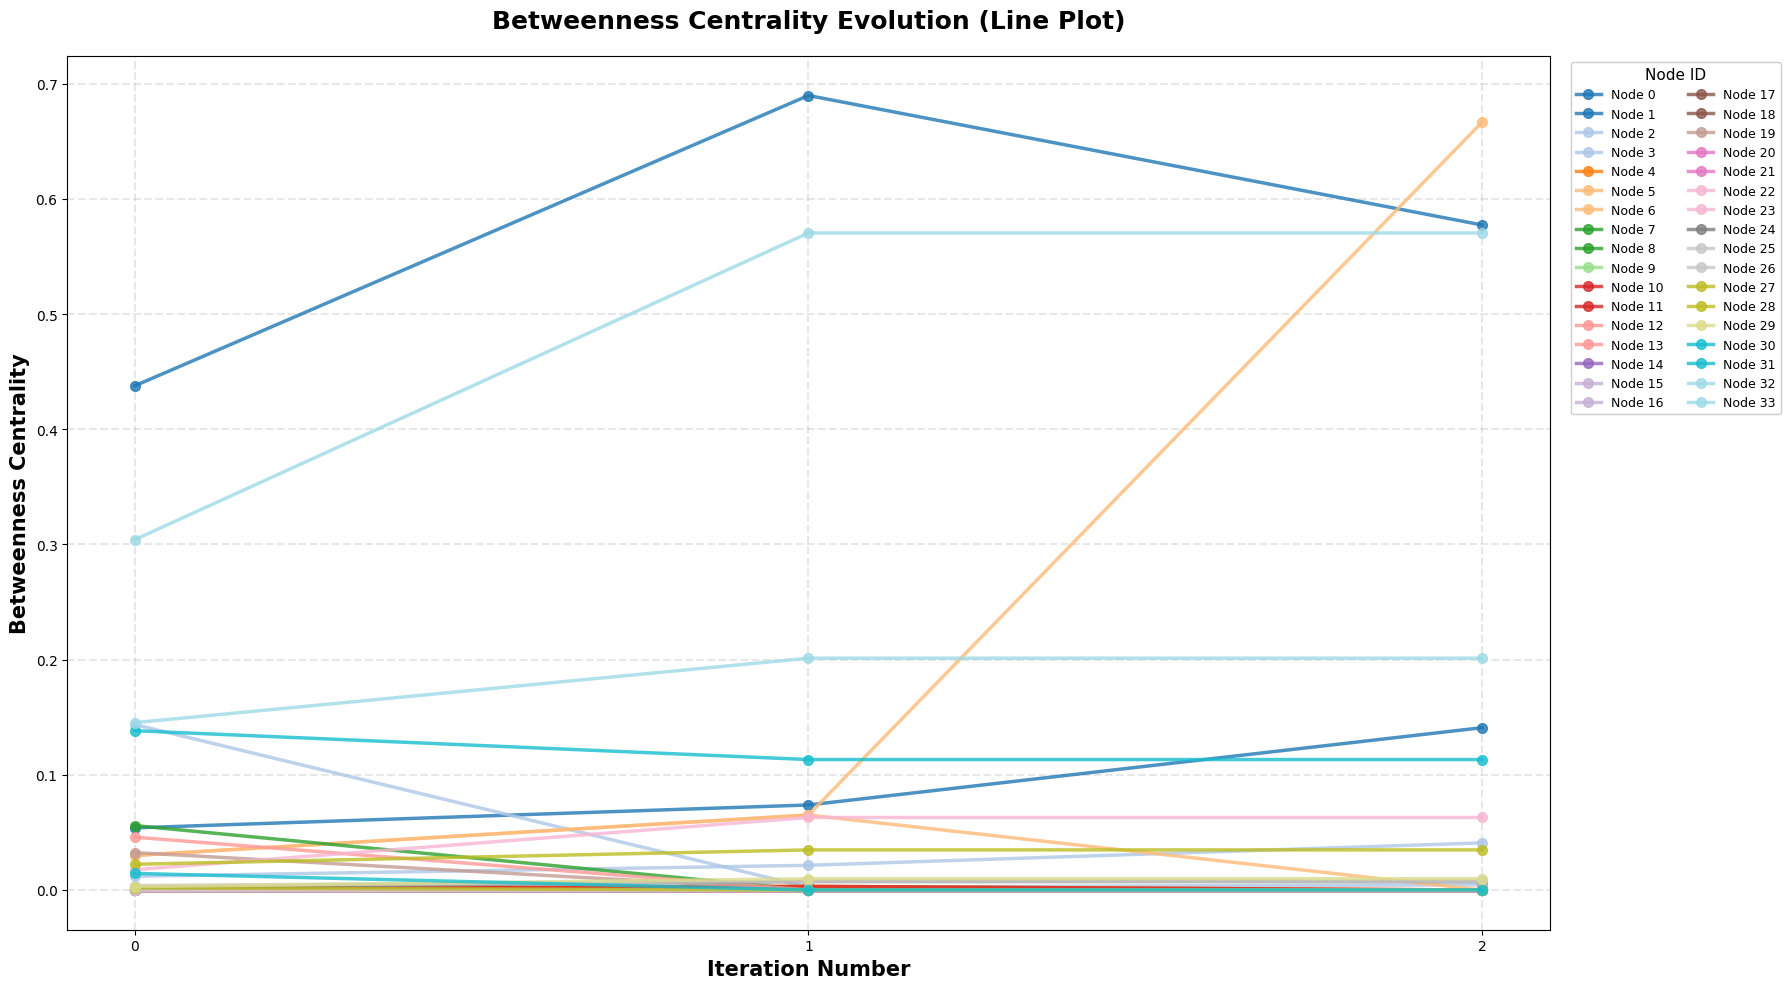

  Closeness...


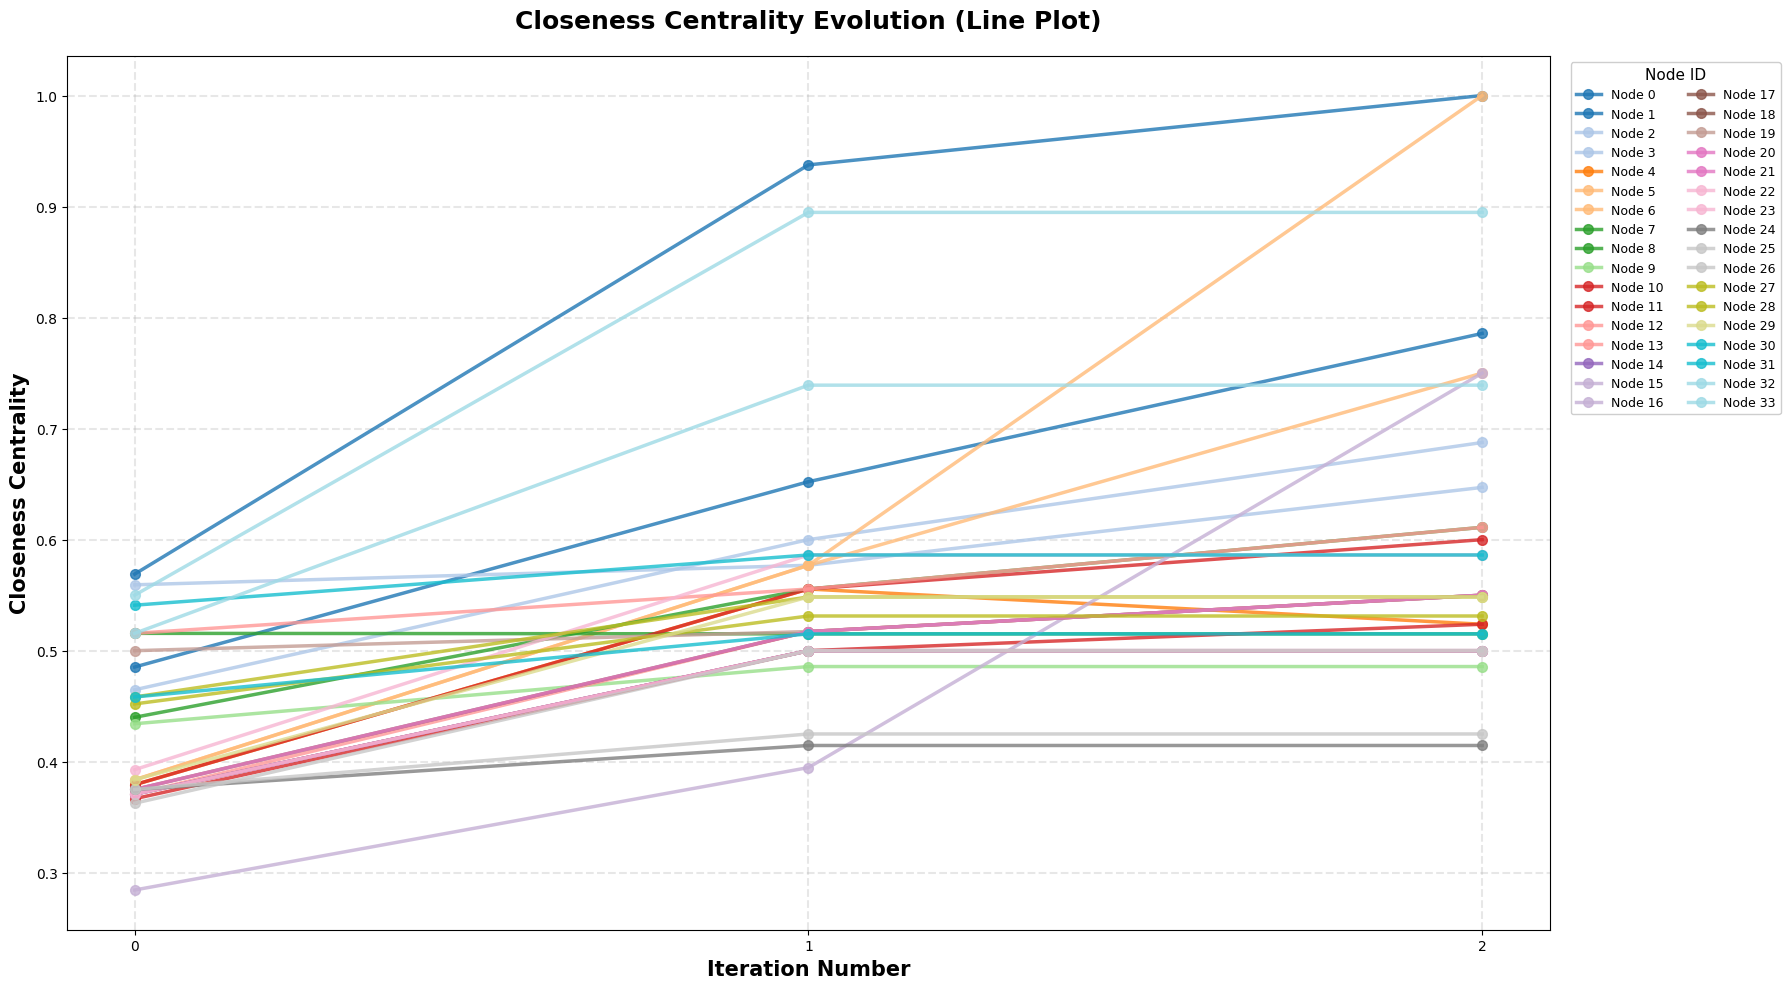

  Clustering...


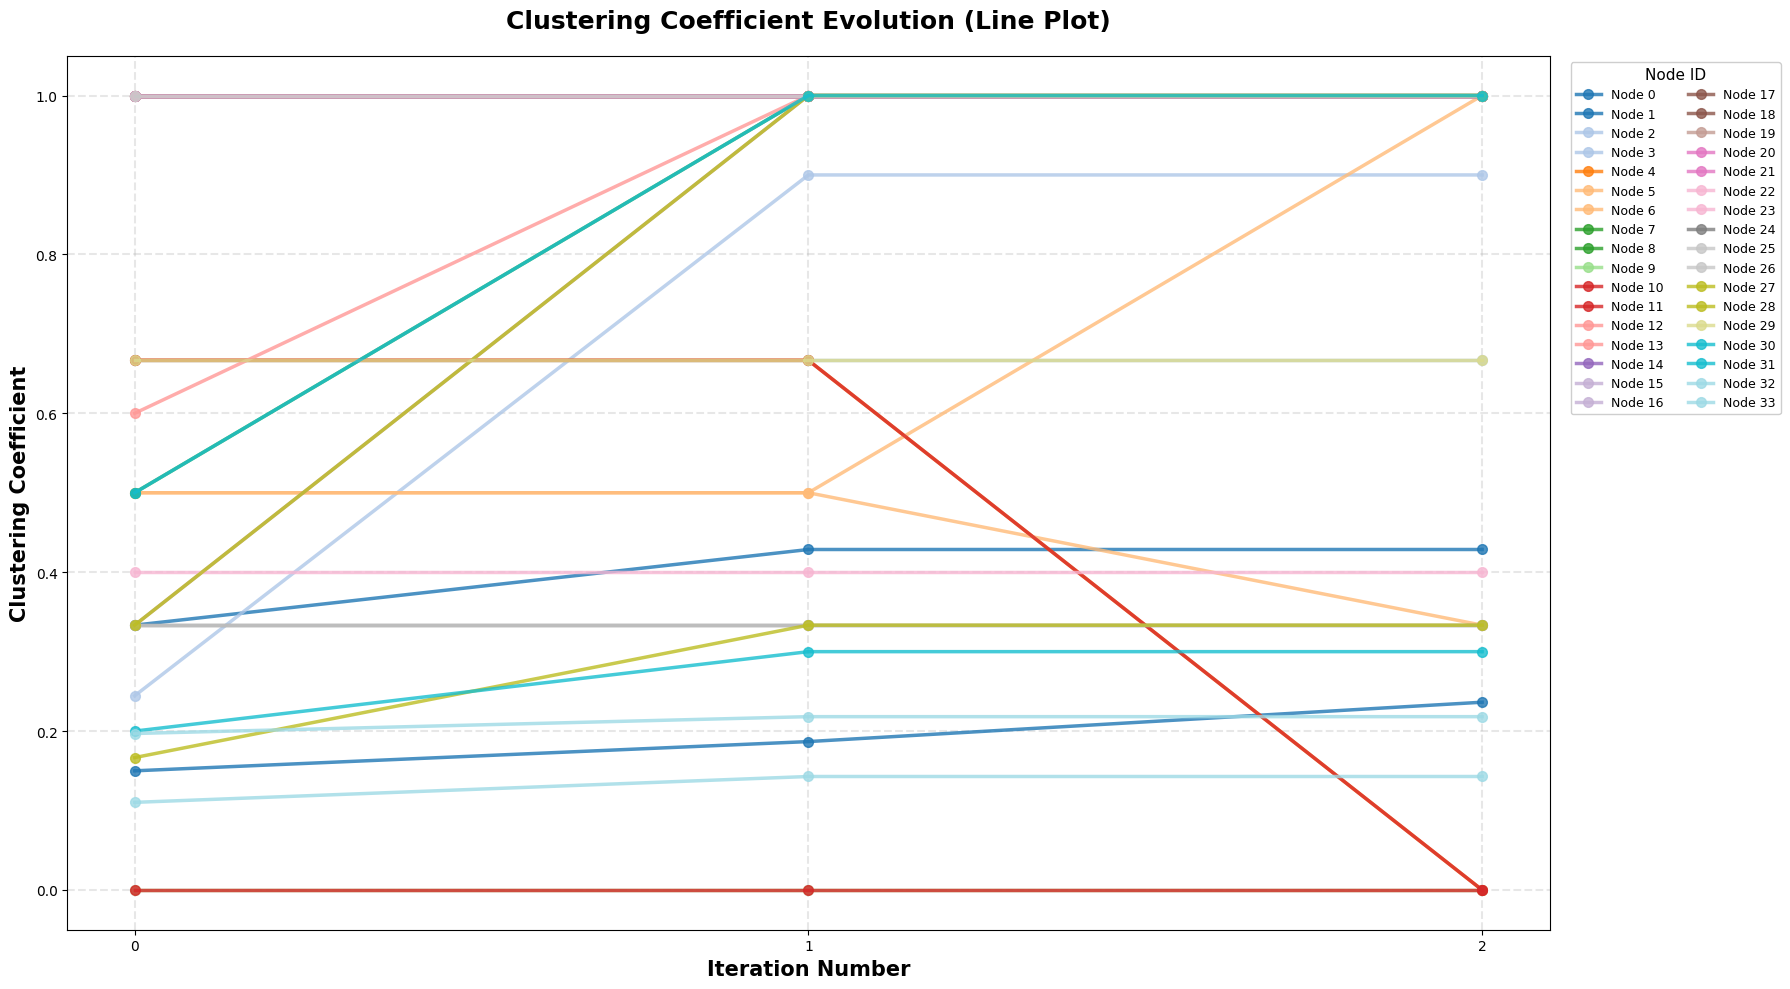


COMPLETE!


In [5]:
# Plot metrics evolution
print("\nGenerating combined metrics plot...")
plot_metrics_evolution('karate_metrics_evolution.png')

print("\nGenerating individual metric plots...")
for metric in ['degree', 'betweenness', 'closeness', 'clustering']:
    print(f"  {metric.capitalize()}...")
    plot_individual_metric_line(metric, f'karate_metric_{metric}_line.png')

print("\n" + "="*70)
print("COMPLETE!")
print("="*70)